In [1]:
# --- imports ---

import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
import re
import matplotlib.pyplot as plt
import seaborn as sns

# disable seaborn warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Basics settings: 

# put as basepath the git repository root
ROOT_PROJECT_DIR = os.popen("git rev-parse --show-toplevel").read().strip()
DATA_DIR = os.path.join(ROOT_PROJECT_DIR, "00-tsdb-bench", "results")

CORES = ["4", "8", "12", "16", "18"]
RAM = ["8", "16", "32", "64"]
NITER = 10 

print("Script running with the following configuration:\n")
print("ROOT_PROJECT_DIR: %s" % ROOT_PROJECT_DIR)
print("DATA_DIR: %s" % DATA_DIR)
print("CORES: %s" % CORES)
print("RAM: %s" % RAM)
print("NITER: %d\n" % NITER)

Script running with the following configuration:

ROOT_PROJECT_DIR: /Users/isacpasianotto/Desktop/workdirectoy/infrastructure-level-data-collection
DATA_DIR: /Users/isacpasianotto/Desktop/workdirectoy/infrastructure-level-data-collection/00-tsdb-bench/results
CORES: ['4', '8', '12', '16', '18']
RAM: ['8', '16', '32', '64']
NITER: 10



In [3]:
# function to read the log file for load test results
def read_log(logfile):
    """
    Reads a log file, searches for a line containing '(mean rate ...)',
    and extracts the numeric rate value (e.g. 822670.70) and its unit (e.g. metrics/sec).
    Returns the numeric rate as float, or None if not found.
    """
    with open(logfile, 'r') as f:
        for line in f:
            if '(mean rate' in line:
                # Debug print
                # print(f"---------- debug -------\n{line}\n-----------------------")

                # Extract numeric value and unit
                match = re.search(r'\(mean rate\s+([\d,\.]+)\s+([a-zA-Z/]+)\)', line)
                if match:
                    value_str = match.group(1).replace(',', '')  # remove commas if any
                    unit = match.group(2)
                    value = float(value_str)
                    return value

    return None

# Example test
# log_path = os.path.join(DATA_DIR, "influx/influx_load_ram8Gi_cores18_iter8.log")
# print(read_log(log_path))

In [4]:
data = pd.DataFrame(columns=["db", "ram", "cpus", "id", "rows/sec"])

In [5]:
def load_database_results(db_name, file_prefix, data_dir_path, file_suffix=".log", use_gi_suffix=True):
    """
    Load benchmark results for a specific database.
    
    Args:
        db_name: Name of the database (e.g., 'influx', 'questdb', 'timescale')
        file_prefix: Prefix of the log files (e.g., 'influx_load_')
        data_dir_path: Full path to the directory containing log files
        file_suffix: Suffix of log files (default: ".log")
        use_gi_suffix: Whether to append 'Gi' to RAM values in filename (default: True)
    
    Returns:
        DataFrame with columns: db, ram, cpus, id, rows/sec
    """
    db_data = pd.DataFrame(columns=["db", "ram", "cpus", "id", "rows/sec"])
    
    for r in RAM:
        for c in CORES:
            for iter_id in range(1, NITER + 1):
                # Build filename with or without 'Gi' suffix
                ram_str = f"{r}Gi" if use_gi_suffix else r
                filename = f"{file_prefix}ram{ram_str}_cores{c}_iter{iter_id}{file_suffix}"
                filepath = os.path.join(data_dir_path, filename)
                
                if os.path.exists(filepath):
                    rows_per_sec = read_log(filepath)
                    if rows_per_sec is None:
                        print(f"Warning: No valid data found in {filepath}")
                        continue
                    row = [db_name, int(r), int(c), iter_id, rows_per_sec]
                    db_data.loc[len(db_data)] = row
                else:
                    print(f"Warning: File {filepath} does not exist")
    
    return db_data

In [6]:
# Load all databases
influx_data = load_database_results(
    db_name="influx",
    file_prefix="influx_load_",
    data_dir_path=os.path.join(DATA_DIR, "influx"),
    use_gi_suffix=True
)

questdb_data = load_database_results(
    db_name="questdb",
    file_prefix="questdb_load_",
    data_dir_path=os.path.join(DATA_DIR, "questdb"),
    use_gi_suffix=True
)

timescale_data = load_database_results(
    db_name="timescale",
    file_prefix="timescale_load_",
    data_dir_path=os.path.join(DATA_DIR, "timescale"),
    use_gi_suffix=False
)

timescale_singlepod = load_database_results(
    db_name="timescalesinglepod",
    file_prefix="timescalesinglepod_load_",
    data_dir_path=os.path.join(DATA_DIR, "timescale-singlepod"),
    use_gi_suffix=False
)

In [7]:

# Concatenate all data
load_data = pd.concat([influx_data, questdb_data, timescale_data, timescale_singlepod], ignore_index=True)
load_data
# print(load_data)

,db,ram,cpus,id,rows/sec
0,influx,8,4,1,260434.73
1,influx,8,4,2,257345.16
2,influx,8,4,3,261417.80
3,influx,8,4,4,252954.21
4,influx,8,4,5,260490.65
...,...,...,...,...,...
795,timescalesinglepod,64,18,6,535831.12
796,timescalesinglepod,64,18,7,535357.86
797,timescalesinglepod,64,18,8,534898.09
798,timescalesinglepod,64,18,9,540478.63


In [8]:
# compute the aggregated mean and standard deviation for the rows/sec column, grouped by db, ram, and cpus
agg_data = load_data.groupby(["db", "ram", "cpus"]).agg(
    mean_rows_per_sec=pd.NamedAgg(column="rows/sec", aggfunc="mean"),
    std_rows_per_sec=pd.NamedAgg(column="rows/sec", aggfunc="std")
).reset_index()

In [9]:
print(agg_data)

                    db  ram  cpus  mean_rows_per_sec  std_rows_per_sec
0               influx    8     4         259421.582       3593.011192
1               influx    8     8         533839.594       3927.573720
2               influx    8    12         739527.997       6688.091307
3               influx    8    16        1679940.501      33174.684538
4               influx    8    18        1876914.473      36667.138490
..                 ...  ...   ...                ...               ...
75  timescalesinglepod   64     4         432765.845      12006.752853
76  timescalesinglepod   64     8         541346.556      10254.871936
77  timescalesinglepod   64    12         542476.274       4031.539527
78  timescalesinglepod   64    16         537163.417       6715.065142
79  timescalesinglepod   64    18         539111.346       4205.502362

[80 rows x 5 columns]


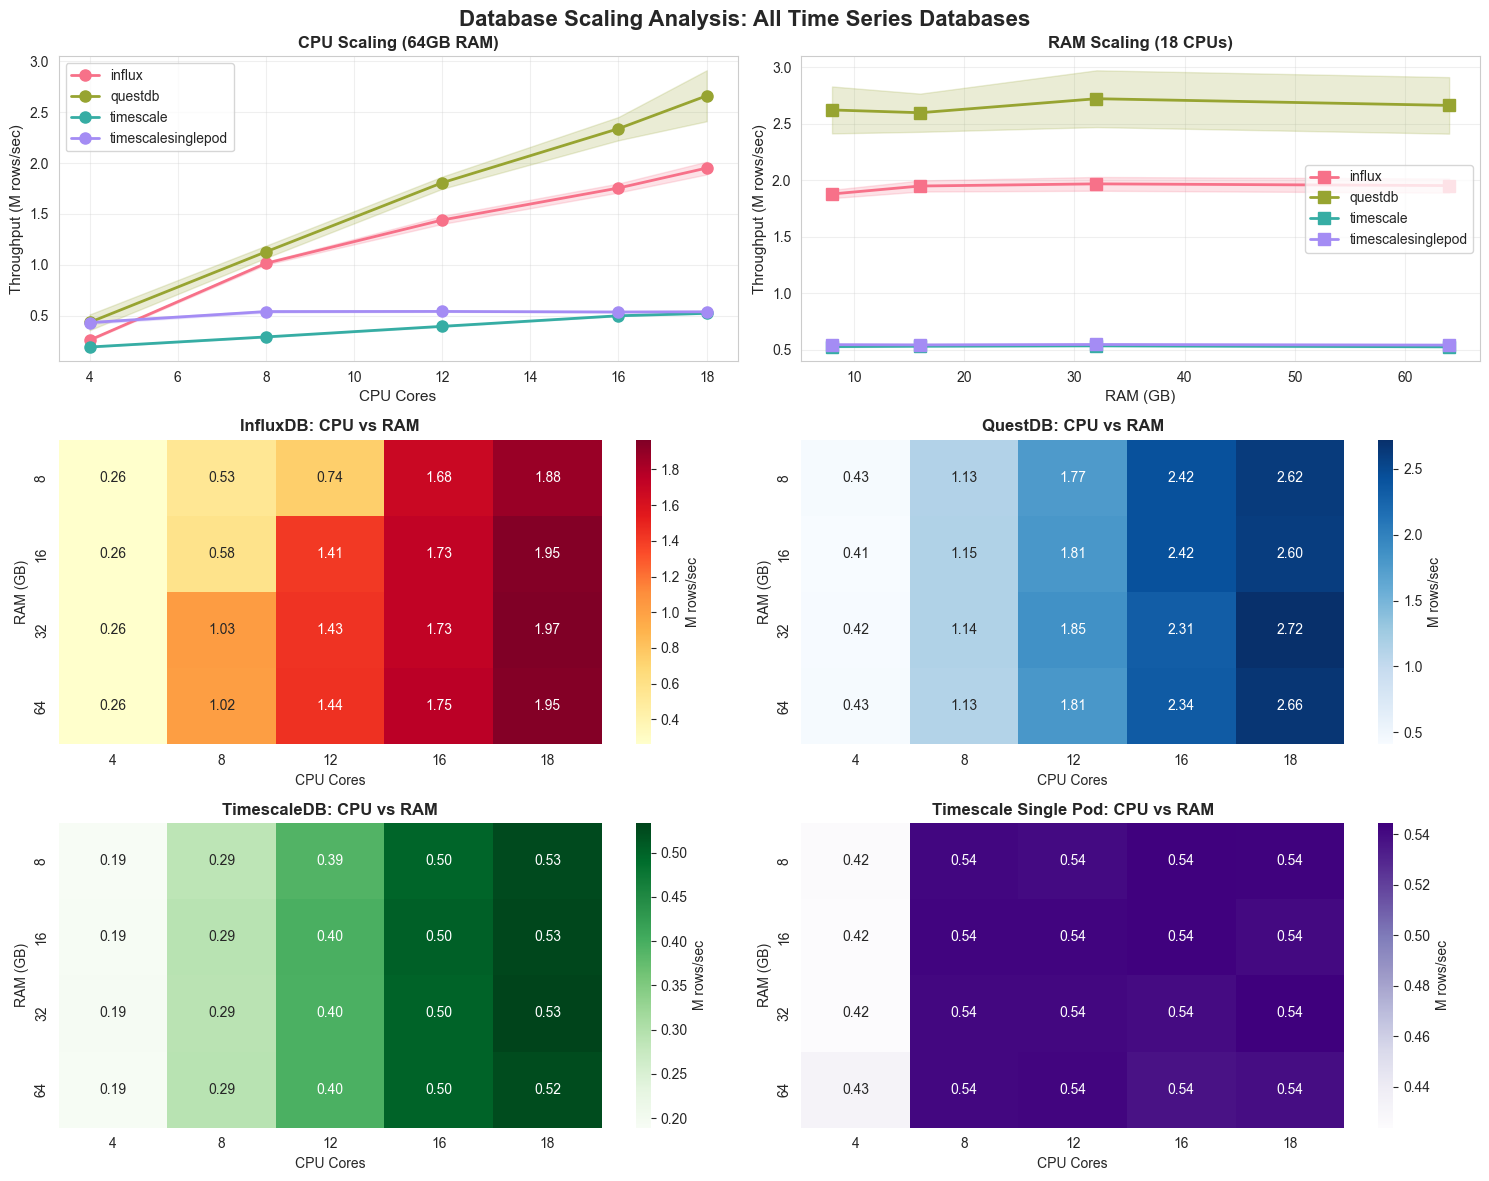


SUMMARY STATISTICS

INFLUX:
  Min throughput: 0.26 M rows/sec
  Max throughput: 1.97 M rows/sec
  Mean throughput: 1.19 M rows/sec
  Scaling (3→9 CPUs): nanx
  Scaling (3→18 CPUs): nanx

QUESTDB:
  Min throughput: 0.41 M rows/sec
  Max throughput: 2.72 M rows/sec
  Mean throughput: 1.68 M rows/sec
  Scaling (3→9 CPUs): nanx
  Scaling (3→18 CPUs): nanx

TIMESCALE:
  Min throughput: 0.19 M rows/sec
  Max throughput: 0.53 M rows/sec
  Mean throughput: 0.38 M rows/sec
  Scaling (3→9 CPUs): nanx
  Scaling (3→18 CPUs): nanx

TIMESCALESINGLEPOD:
  Min throughput: 0.42 M rows/sec
  Max throughput: 0.54 M rows/sec
  Mean throughput: 0.52 M rows/sec
  Scaling (3→9 CPUs): nanx
  Scaling (3→18 CPUs): nanx


In [10]:
# Convert to millions of rows/sec
agg_data['throughput_M'] = agg_data['mean_rows_per_sec'] / 1e6
agg_data['std_M'] = agg_data['std_rows_per_sec'] / 1e6

# Set up the plotting style
sns.set_style("whitegrid")
colors = sns.color_palette("husl", agg_data['db'].nunique())
db_colors = {db: colors[i] for i, db in enumerate(agg_data['db'].unique())}

# Create figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Database Scaling Analysis: All Time Series Databases', fontsize=16, fontweight='bold')

# 1. CPU Scaling (fixed RAM at 16GB)
ax1 = axes[0, 0]
for db in agg_data['db'].unique():
    subset = agg_data[(agg_data['db'] == db) & (agg_data['ram'] == 64)]
    subset = subset.sort_values('cpus')
    ax1.plot(subset['cpus'], subset['throughput_M'], marker='o', label=db, 
             color=db_colors[db], linewidth=2, markersize=8)
    ax1.fill_between(subset['cpus'], 
                      subset['throughput_M'] - subset['std_M'], 
                      subset['throughput_M'] + subset['std_M'],
                      color=db_colors[db], alpha=0.2)
ax1.set_xlabel('CPU Cores', fontsize=11)
ax1.set_ylabel('Throughput (M rows/sec)', fontsize=11)
ax1.set_title('CPU Scaling (64GB RAM)', fontsize=12, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 2. RAM Scaling (fixed CPUs at 18)
ax2 = axes[0, 1]
for db in agg_data['db'].unique():
    subset = agg_data[(agg_data['db'] == db) & (agg_data['cpus'] == 18)]
    subset = subset.sort_values('ram')
    ax2.plot(subset['ram'], subset['throughput_M'], marker='s', label=db, 
             color=db_colors[db], linewidth=2, markersize=8)
    ax2.fill_between(subset['ram'], 
                      subset['throughput_M'] - subset['std_M'], 
                      subset['throughput_M'] + subset['std_M'],
                      color=db_colors[db], alpha=0.2)
ax2.set_xlabel('RAM (GB)', fontsize=11)
ax2.set_ylabel('Throughput (M rows/sec)', fontsize=11)
ax2.set_title('RAM Scaling (18 CPUs)', fontsize=12, fontweight='bold')
ax2.legend(loc='right')
ax2.grid(True, alpha=0.3)

# 3. Heatmap: CPUs vs RAM for InfluxDB
ax3 = axes[1, 0]
pivot_data = agg_data[agg_data['db'] == 'influx'].pivot_table(
    values='throughput_M', index='ram', columns='cpus'
)
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax3, cbar_kws={'label': 'M rows/sec'})
ax3.set_title('InfluxDB: CPU vs RAM', fontsize=12, fontweight='bold')
ax3.set_xlabel('CPU Cores')
ax3.set_ylabel('RAM (GB)')

# 4. Heatmap: CPUs vs RAM for QuestDB
ax4 = axes[1, 1]
pivot_data = agg_data[agg_data['db'] == 'questdb'].pivot_table(
    values='throughput_M', index='ram', columns='cpus'
)
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='Blues', ax=ax4, cbar_kws={'label': 'M rows/sec'})
ax4.set_title('QuestDB: CPU vs RAM', fontsize=12, fontweight='bold')
ax4.set_xlabel('CPU Cores')
ax4.set_ylabel('RAM (GB)')

# 5. Heatmap: CPUs vs RAM for TimescaleDB
ax5 = axes[2, 0]
pivot_data = agg_data[agg_data['db'] == 'timescale'].pivot_table(
    values='throughput_M', index='ram', columns='cpus'
)
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='Greens', ax=ax5, cbar_kws={'label': 'M rows/sec'})
ax5.set_title('TimescaleDB: CPU vs RAM', fontsize=12, fontweight='bold')
ax5.set_xlabel('CPU Cores')
ax5.set_ylabel('RAM (GB)')

# 6. Heatmap: CPUs vs RAM for Timescale Single Pod
ax6 = axes[2, 1]
pivot_data = agg_data[agg_data['db'] == 'timescalesinglepod'].pivot_table(
    values='throughput_M', index='ram', columns='cpus'
)
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='Purples', ax=ax6, cbar_kws={'label': 'M rows/sec'})
ax6.set_title('Timescale Single Pod: CPU vs RAM', fontsize=12, fontweight='bold')
ax6.set_xlabel('CPU Cores')
ax6.set_ylabel('RAM (GB)')

# Apply tight layout and show the figure only once at the end
plt.tight_layout()
# plt.savefig("/home/pasianeight/db_scaling_analysis_all_dbs.png", dpi=900)

plt.show()



# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
for db in agg_data['db'].unique():
    db_data = agg_data[agg_data['db'] == db]
    print(f"\n{db.upper()}:")
    print(f"  Min throughput: {db_data['throughput_M'].min():.2f} M rows/sec")
    print(f"  Max throughput: {db_data['throughput_M'].max():.2f} M rows/sec")
    print(f"  Mean throughput: {db_data['throughput_M'].mean():.2f} M rows/sec")
    
    # CPU scaling efficiency (3 CPUs baseline)
    baseline_3cpu = db_data[db_data['cpus'] == 3]['throughput_M'].mean()
    scaling_9cpu = db_data[db_data['cpus'] == 9]['throughput_M'].mean()
    scaling_18cpu = db_data[db_data['cpus'] == 18]['throughput_M'].mean()
    print(f"  Scaling (3→9 CPUs): {scaling_9cpu/baseline_3cpu:.2f}x")
    print(f"  Scaling (3→18 CPUs): {scaling_18cpu/baseline_3cpu:.2f}x")

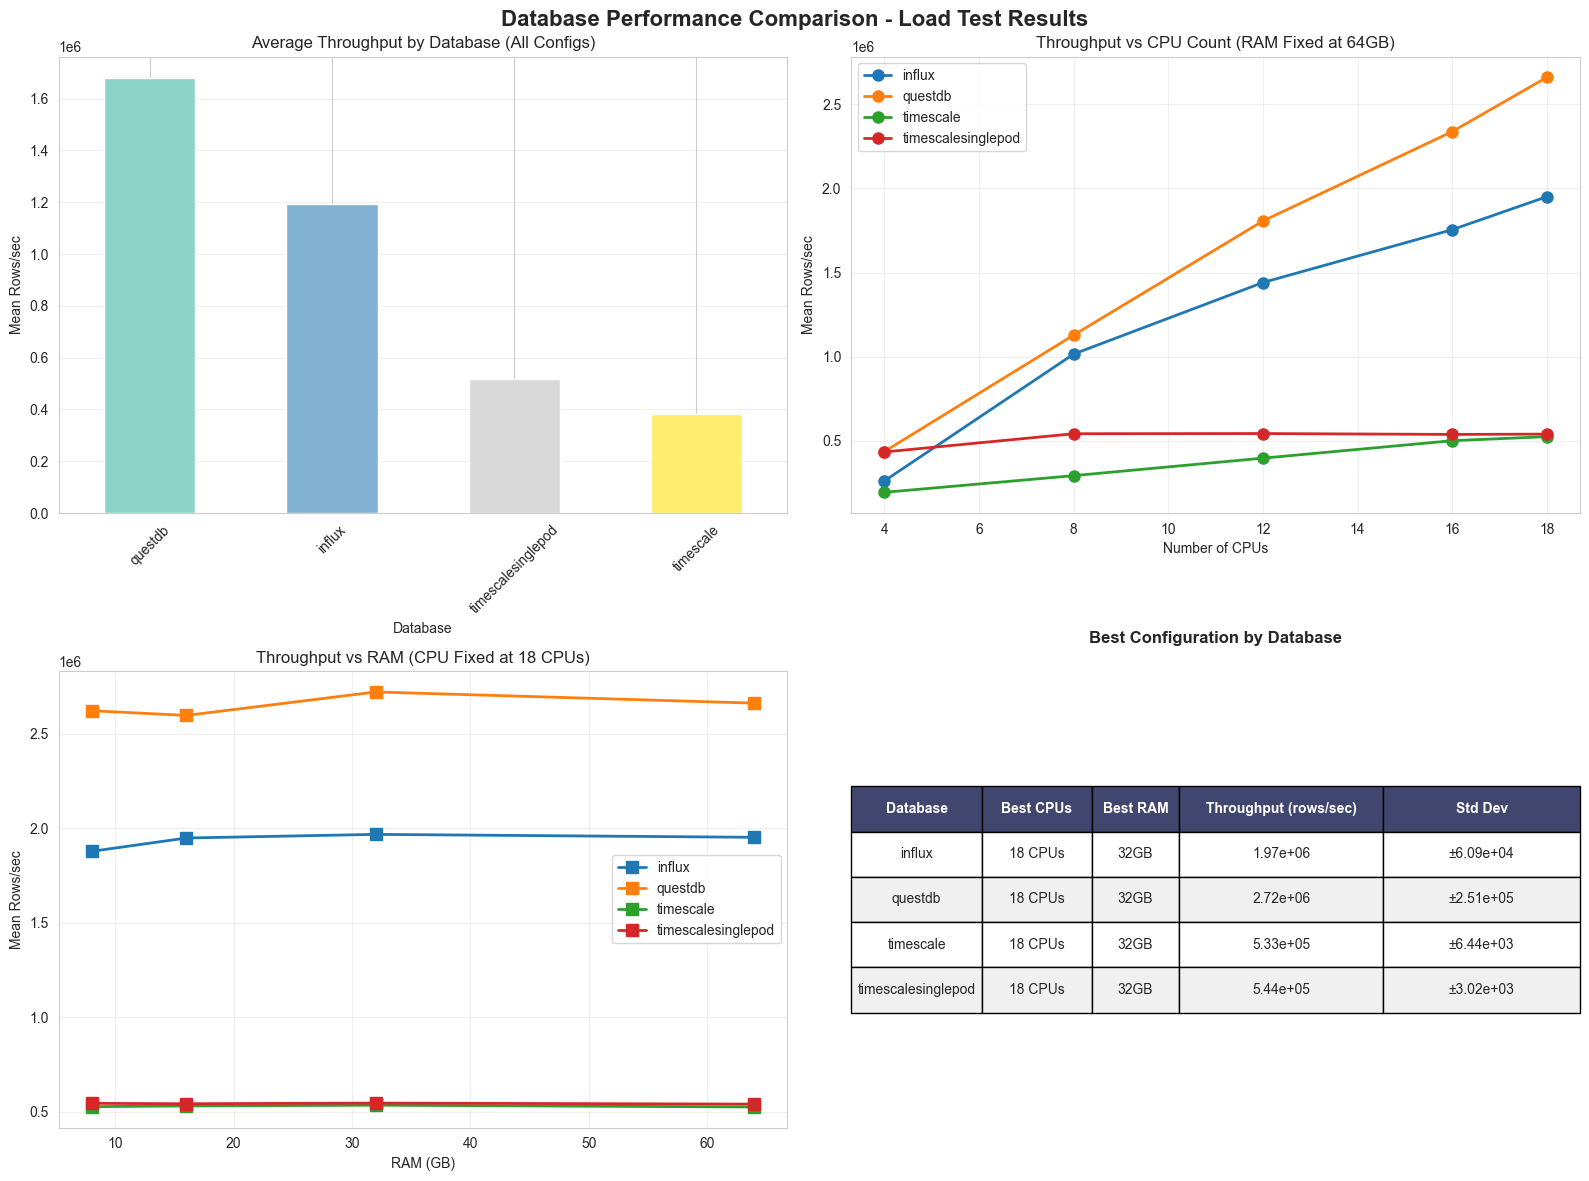


=== PERFORMANCE AT SAME RESOURCE LEVELS ===

64GB RAM, 18 CPUs (Maximum Configuration):
                db  mean_rows_per_sec  std_rows_per_sec
           questdb        2661093.920     250203.017543
            influx        1951116.776      62800.423019
timescalesinglepod         539111.346       4205.502362
         timescale         523977.658       4423.532620

16GB RAM, 3 CPUs (Minimum Configuration):
Empty DataFrame
Columns: [db, mean_rows_per_sec, std_rows_per_sec]
Index: []


In [11]:

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Database Performance Comparison - Load Test Results', fontsize=16, fontweight='bold')

# 1. Mean throughput by database
ax1 = axes[0, 0]
db_means = agg_data.groupby('db')['mean_rows_per_sec'].mean().sort_values(ascending=False)
colors = plt.cm.Set3(np.linspace(0, 1, len(db_means)))
db_means.plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('Average Throughput by Database (All Configs)')
ax1.set_ylabel('Mean Rows/sec')
ax1.set_xlabel('Database')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# 2. Performance by CPU count - FIXED RAM (64GB)
ax2 = axes[0, 1]
ram_fixed = 64
data_fixed = agg_data[agg_data['ram'] == ram_fixed].sort_values('cpus')
for db in data_fixed['db'].unique():
    db_data = data_fixed[data_fixed['db'] == db]
    ax2.plot(db_data['cpus'], db_data['mean_rows_per_sec'], marker='o', label=db, linewidth=2, markersize=8)
ax2.set_title(f'Throughput vs CPU Count (RAM Fixed at {ram_fixed}GB)')
ax2.set_ylabel('Mean Rows/sec')
ax2.set_xlabel('Number of CPUs')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Performance by RAM - FIXED CPU (18 CPUs)
ax3 = axes[1, 0]
cpu_fixed = 18
data_fixed = agg_data[agg_data['cpus'] == cpu_fixed].sort_values('ram')
for db in data_fixed['db'].unique():
    db_data = data_fixed[data_fixed['db'] == db]
    ax3.plot(db_data['ram'], db_data['mean_rows_per_sec'], marker='s', label=db, linewidth=2, markersize=8)
ax3.set_title(f'Throughput vs RAM (CPU Fixed at {cpu_fixed} CPUs)')
ax3.set_ylabel('Mean Rows/sec')
ax3.set_xlabel('RAM (GB)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Heatmap-style: best config for each DB
ax4 = axes[1, 1]
ax4.axis('off')

# Get best config for each database
summary_data = []
for db in sorted(agg_data['db'].unique()):
    db_data = agg_data[agg_data['db'] == db]
    best_idx = db_data['mean_rows_per_sec'].idxmax()
    best_row = db_data.loc[best_idx]
    summary_data.append([
        db,
        f"{best_row['cpus']} CPUs",
        f"{best_row['ram']}GB",
        f"{best_row['mean_rows_per_sec']:.2e}",
        f"±{best_row['std_rows_per_sec']:.2e}"
    ])

# Create table
table = ax4.table(cellText=summary_data,
                  colLabels=['Database', 'Best CPUs', 'Best RAM', 'Throughput (rows/sec)', 'Std Dev'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.18, 0.15, 0.12, 0.28, 0.27])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color header
for i in range(5):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data) + 1):
    for j in range(5):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

ax4.set_title('Best Configuration by Database', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Detailed comparison at same resource levels
print("\n=== PERFORMANCE AT SAME RESOURCE LEVELS ===\n")
print("64GB RAM, 18 CPUs (Maximum Configuration):")
best_config = agg_data[(agg_data['ram'] == 64) & (agg_data['cpus'] == 18)].sort_values('mean_rows_per_sec', ascending=False)
print(best_config[['db', 'mean_rows_per_sec', 'std_rows_per_sec']].to_string(index=False))

print("\n16GB RAM, 3 CPUs (Minimum Configuration):")
min_config = agg_data[(agg_data['ram'] == 16) & (agg_data['cpus'] == 3)].sort_values('mean_rows_per_sec', ascending=False)
print(min_config[['db', 'mean_rows_per_sec', 'std_rows_per_sec']].to_string(index=False))